In [6]:
import sys
from pathlib import Path
import country_converter as coco
import matplotlib.pyplot as plt
import re
import pandas as pd
import math
import numpy as np
from uncertainties import ufloat, nominal_value, std_dev
from uncertainties.core import CallableStdDev

# ---------------------------- Run from Repo Root ----------------------------
BASE_DIR = Path.cwd().parent
sys.path.append(str(BASE_DIR))

# ---------------------------- File Paths ----------------------------
output_path = BASE_DIR / "results" / "Scale_up_output_MS.csv"
ecw_country = BASE_DIR / "results" / "ECWbyCountry.csv"
ecw_region = BASE_DIR / "results" / "ECWbyRegion.csv"

In [7]:
# ---------- Core Functions ----------

def get_series(df, region):
    """Return time (weeks), nominal values, and uncertainties for a single country."""
    if region not in df.index:
        raise ValueError(f"{region} not found in DataFrame index")

    row = df.loc[region]  # Series of ufloats
    row = row.iloc[2:]
    time = np.arange(len(row))
    values = np.array([nominal_value(v) for v in row])
    errors = np.array([std_dev(v) for v in row])
    return time, values, errors

def get_ECW(df, region):
    row = df.loc[region]
    ECW_Upper = row[1]
    ECW_Lower = row[0]
    return ECW_Lower, ECW_Upper

def plot_region(df, region, ax=None, sigma=1):
    """Plot a single country's series with ±sigma bands."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(10,6))
    
    t, vals, errs = get_series(df, region)

    ecw_lower, ecw_upper = get_ECW(df, region)
    CADR_lower = CADRPP*ecw_lower
    CADR_upper = CADRPP*ecw_upper

    ax.axhspan(CADR_lower, CADR_upper, alpha=0.15, 
        label=f'CADR Range ({CADR_lower:.1f}-{CADR_upper:.1f})')
    
    ax.plot(t, vals, label=region)
    ax.fill_between(t, vals - sigma*errs, vals + sigma*errs, alpha=0.3)
    ax.set_title(f"{region} Scale Up with ±{sigma}σ bands ")
    ax.set_xlabel("Weeks")
    ax.set_ylabel("Value")
    ax.legend()
    return ax

def plot_multiple_regions(df, region, sigma=1):
    """Plot multiple countries together."""
    fig, ax = plt.subplots(figsize=(12,8))
    for c in region:
        plot_region(df, c, ax=ax, sigma=sigma)
    plt.title(f"Multiple Regions series with ±{sigma}σ bands")
    plt.show()


In [8]:
## ---------------------------- Varaibles ---------------------------- 

CADRPP = 50 # L/s
UNRegion_list = ['Australia and New Zealand',
 'Caribbean',
 'Central America',
 'Central Asia',
 'Eastern Africa',
 'Eastern Asia',
 'Eastern Europe',
 'Melanesia',
 'Micronesia',
 'Middle Africa',
 'Northern Africa',
 'Northern America',
 'Northern Europe',
 'Polynesia',
 'South America',
 'South-eastern Asia',
 'Southern Africa',
 'Southern Asia',
 'Southern Europe',
 'Western Africa',
 'Western Asia',
 'Western Europe']

[0.00000000e+00 8.47007314e+06 2.04300575e+08 2.12770648e+08
 2.30946938e+08 2.39417011e+08 2.51517115e+08 2.63617220e+08
 2.75717324e+08 2.87817429e+08 2.99917533e+08 3.12017638e+08
 3.24117742e+08 3.36217847e+08 3.48317951e+08 3.60418056e+08
 3.72518160e+08 3.84618264e+08 3.96718369e+08 4.08818473e+08
 4.20918578e+08 4.33018682e+08 4.45118787e+08 4.57218891e+08
 4.69318996e+08 4.81419100e+08 4.93519205e+08 5.05619309e+08
 5.17719414e+08 5.29819518e+08 5.41919623e+08 5.54019727e+08
 5.66119832e+08 5.78219936e+08 5.90320041e+08 6.02420145e+08
 6.14520250e+08 6.26620354e+08 6.38720459e+08 6.50820563e+08
 6.62920668e+08 6.75020772e+08 6.87120877e+08 6.99220981e+08
 7.11321086e+08 7.23421190e+08 7.35521294e+08 7.47621399e+08
 7.59721503e+08 7.71821608e+08 7.83921712e+08 7.96021817e+08
 8.08121921e+08]


<Axes: title={'center': 'Belgium Scale Up with ±2σ bands '}, xlabel='Weeks', ylabel='Value'>

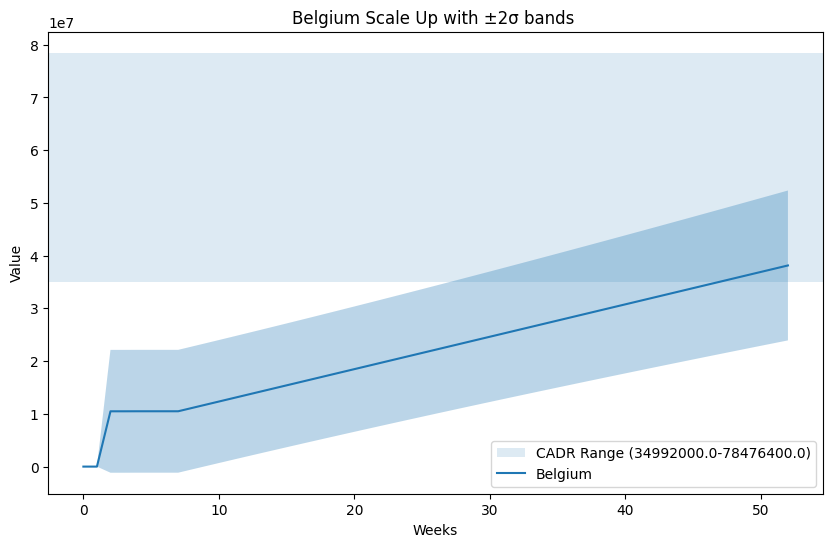

In [12]:
## ---------------------------- Scale Up Plotting for Tester ---------------------------- 
df_loaded = pd.read_pickle(output_path.with_suffix(".pkl"))

print(get_series(df_loaded, 'Germany')[1])

plot_region(df_loaded, "Belgium", sigma=2)

# plot_multiple_regions(df_loaded, ["Eastern Asia", "Northern America", "Northern Europe"], sigma =2)

# for i in UNRegion_list:
#     plot_region(df_loaded, i, sigma=1)
